<Axes: title={'center': 'cross section at z=0.00'}, xlabel='x', ylabel='y'>

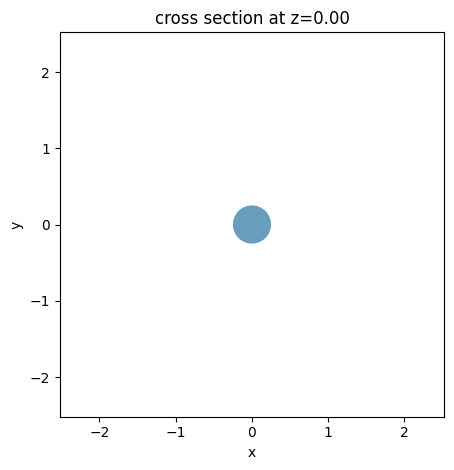

In [1]:
import tidy3d as td
import numpy as np

# size of simulation domain
r = 1.0 / 4  # radius of sphere

wvl_min = 2*np.pi*r/10 * 4
wvl_max = 2*np.pi*r/1

frq_min = 1/wvl_max
frq_max = 1/wvl_min
frq_cen = 0.5*(frq_min+frq_max)

dpml = 0.5*wvl_max
dair = 0.5*wvl_max

## at least 8 pixels per smallest wavelength, i.e. np.floor(8/wvl_min)
resolution = 25
dl = 1/resolution
s = 2*(dpml+dair+r) + 1.4
n_sphere = 2
# automatic grid specification
# grid_spec = td.GridSpec.auto(min_steps_per_wvl=20, wavelength=wvl_um)
grid_spec = td.GridSpec.uniform(dl=dl)
geometry = td.Sphere(center=(0, 0, 0), radius=r)

path_prefix = "D:\\workspace\\mymeep\\cmake-build-debug-visual-studio\\libcore\\"

waveguide = td.Structure(
    geometry=geometry,
    medium=td.Medium.from_nk(n_sphere, 0, frq_cen),
)

sim = td.Simulation(
    size=(s, s, s),
    grid_spec=grid_spec,
    structures=[waveguide],
    run_time=1e-12,
    boundary_spec=td.BoundarySpec.all_sides(boundary=td.Periodic()),
)

sim.plot(z=0.0)

In [2]:
import custom.spatial_medium as sm

creator = sm.SpatialMediumCreator4(sim)

medium, cell_permittivity = creator.create()

process total cells: 43264 on 20 cores, iterations: None
Calc Time elapsed: 284.4635769000015


[4.]


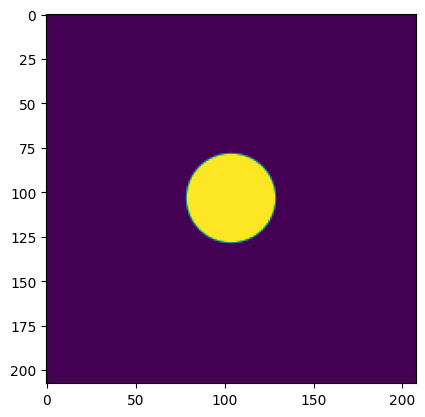

In [8]:
# vis
import matplotlib.pyplot as plt
print(cell_permittivity[100,100]);
plt.imshow(cell_permittivity.squeeze())

In [4]:
# save as npy
np.save(path_prefix +"sphere_medium-4.npy", cell_permittivity)

In [1]:
creator = sm.SpatialMediumCreator5(sim)

_, cell_permittivity = creator.create()

NameError: name 'sm' is not defined

In [1]:
plt.imshow(cell_permittivity)
np.save(path_prefix +"sphere_medium-5.npy", cell_permittivity)

NameError: name 'plt' is not defined